# Stacking Regressor - Insurance Charges Prediction

## 1. Load Insurance Dataset
Load the insurance dataset from the stacking regression folder and verify the file path.

In [17]:
import pandas as pd
from pathlib import Path

pd.set_option("display.max_columns", None)

data_path = Path("insurance.csv")
if not data_path.exists():
    raise FileNotFoundError(f"Dataset not found at: {data_path.resolve()}")

df = pd.read_csv(data_path)
print("Shape:", df.shape)
df.head()

Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 2. Inspect and Clean Data
Display schema, handle missing values, fix data types, and remove or impute invalid rows.

In [18]:
df.info()

# Basic cleanup
numeric_cols = ["age", "bmi", "children", "charges"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

for col in ["sex", "smoker", "region"]:
    df[col] = df[col].astype(str).str.strip().str.lower()

df = df.dropna().reset_index(drop=True)
print("After cleaning:", df.shape)
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
After cleaning: (1338, 7)
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


## 3. Feature Engineering and Encoding
Prepare features, encode categorical variables, and set the target column.

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

X = df.drop(columns=["charges"])
y = df["charges"].copy()

categorical_cols = ["sex", "smoker", "region"]
numeric_features = ["age", "bmi", "children"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ]
)

## 4. Train/Validation/Test Split
Split the dataset into train/validation/test sets with a fixed random seed.

In [20]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (936, 6) Val: (201, 6) Test: (201, 6)


## 5. Define Base Models
Instantiate base regressors with consistent pipelines.

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor

base_models = {
    "Linear Regression": Pipeline(
        [("preprocess", preprocess), ("model", LinearRegression())]
    ),
    "KNN": Pipeline(
        [("preprocess", preprocess), ("model", KNeighborsRegressor(n_neighbors=5))]
    ),
    "SVR (RBF)": Pipeline(
        [("preprocess", preprocess), ("model", SVR(kernel="rbf"))]
    ),
    "Decision Tree": Pipeline(
        [("preprocess", preprocess), ("model", DecisionTreeRegressor(random_state=42))]
    ),
    "Random Forest": Pipeline(
        [
            ("preprocess", preprocess),
            ("model", RandomForestRegressor(n_estimators=50, random_state=42)),
        ]
    ),
}

## 6. Train and Evaluate Individual Base Models
Train each model, generate predictions, and compute evaluation metrics.

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def evaluate_model(name, model, X_train, y_train, X_eval, y_eval):
    model.fit(X_train, y_train)
    preds = model.predict(X_eval)
    rmse = mean_squared_error(y_eval, preds, squared=False)
    metrics = {
        "model": name,
        "mae": mean_absolute_error(y_eval, preds),
        "rmse": rmse,
        "r2": r2_score(y_eval, preds),
    }
    return metrics, model

results = []
trained_models = {}

for name, model in base_models.items():
    def evaluate_model(name, model, X_train, y_train, X_eval, y_eval):
        model.fit(X_train, y_train)
        preds = model.predict(X_eval)
        rmse = mean_squared_error(y_eval, preds) ** 0.5
        metrics = {
            "model": name,
            "mae": mean_absolute_error(y_eval, preds),
            "rmse": rmse,
            "r2": r2_score(y_eval, preds),
        }
        return metrics, model

    results = []
    trained_models = {}

    for name, model in base_models.items():
        metrics, fitted = evaluate_model(name, model, X_train, y_train, X_test, y_test)
        results.append(metrics)
        trained_models[name] = fitted

    pd.DataFrame(results).sort_values("rmse")
    results.append(metrics)
    trained_models[name] = fitted

pd.DataFrame(results).sort_values("rmse")

,model,mae,rmse,r2
5,Random Forest,2617.422701,4707.395002,0.853876
4,Random Forest,2617.422701,4707.395002,0.853876
0,Linear Regression,4360.112287,6090.494701,0.755395
1,KNN,3787.924065,6292.315600,0.738916
3,Decision Tree,2884.422956,6317.681190,0.736806
2,SVR (RBF),8462.154856,12933.992978,-0.103126


## 7. Build Stacking Regressor
Create a stacking ensemble using the base models and a meta-learner, then fit it.

In [23]:
estimators = [(name, model) for name, model in base_models.items()]

stacking = StackingRegressor(
    estimators=estimators,
    final_estimator=LinearRegression(),
    passthrough=False,
)

stack_metrics, stacking_model = evaluate_model(
    "Stacking (LR meta)", stacking, X_train, y_train, X_test, y_test
)
results.append(stack_metrics)

print(stack_metrics)

{'model': 'Stacking (LR meta)', 'mae': 2550.1151069726957, 'rmse': 4663.61404981552, 'r2': 0.8565815098359171}


## 8. Evaluate Stacking vs Individual Models
Compare stacking performance against all base models on the test set.

In [24]:
comparison_df = (
    pd.DataFrame(results)
    .sort_values("rmse")
    .reset_index(drop=True)
)
comparison_df

,model,mae,rmse,r2
0,Stacking (LR meta),2550.115107,4663.614050,0.856582
1,Random Forest,2617.422701,4707.395002,0.853876
2,Random Forest,2617.422701,4707.395002,0.853876
3,Linear Regression,4360.112287,6090.494701,0.755395
4,KNN,3787.924065,6292.315600,0.738916
5,Decision Tree,2884.422956,6317.681190,0.736806
6,SVR (RBF),8462.154856,12933.992978,-0.103126


## 9. Performance Comparison Table and Plot
Create a summary table and visualization of model metrics, then save the stacking model.

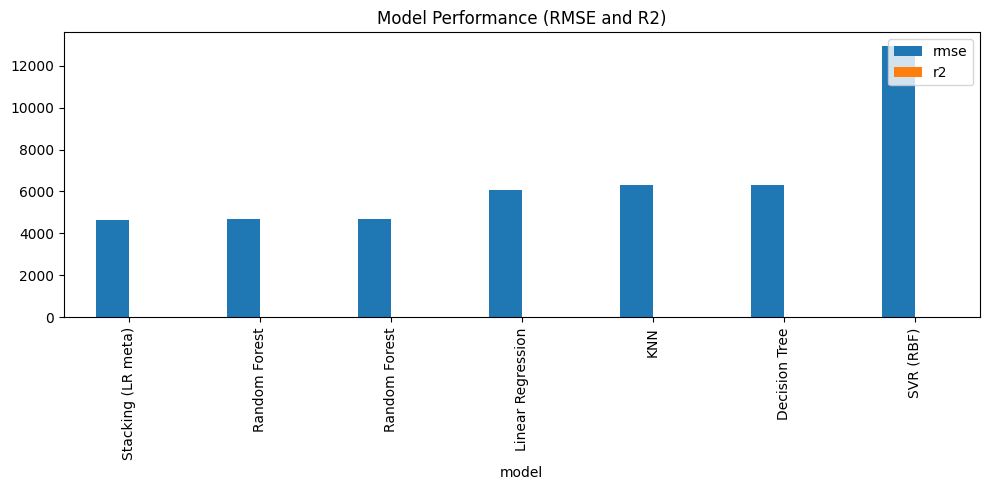

Saved model to stacking_insurance_model.pkl


In [25]:
import matplotlib.pyplot as plt
import joblib

plot_df = comparison_df.set_index("model")[["rmse", "r2"]]
ax = plot_df.plot(kind="bar", figsize=(10, 5))
ax.set_title("Model Performance (RMSE and R2)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

joblib.dump(stacking_model, "stacking_insurance_model.pkl", compress=3)
print("Saved model to stacking_insurance_model.pkl")